# **Credits**

This notebooks and models made by **Puteri Amelia Azli**

16/09/2026

Database source: https://www.kaggle.com/datasets/kapturovalexander/fruits-by-yolo-fruits-detection

*   **GitHub**: https://github.com/puteriazli
*   **LinkedIn**: https://www.linkedin.com/in/puteriazli
*   **Kaggle**: https://www.kaggle.com/puteriameliaazli
*   **YouTube**: https://www.youtube.com/@putericoding

# **Fruits Detection**

In [ ]:
!pip install -q -U ultralytics kagglehub pyyaml pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [ ]:
import kagglehub
from pathlib import Path

DATASET_HANDLE = "kapturovalexander/fruits-by-yolo-fruits-detection"

cache_path = Path(kagglehub.dataset_download(DATASET_HANDLE))
print(f"[INFO] Dataset berhasil didownload ke: {cache_path}")

def find_dataset_paths(root: Path):
    yaml_path = next(root.rglob("data.yaml"), None)
    train_dir = next(root.rglob("train"), None)
    split_root = train_dir.parent if train_dir else None
    return yaml_path, split_root

DATA_YAML_ORIGINAL, BASE_DIR = find_dataset_paths(cache_path)

if DATA_YAML_ORIGINAL is None or BASE_DIR is None:
    raise FileNotFoundError(
        "Tidak ketemu data.yaml atau folder train/ di dataset yang didownload.\n"
        f"Cek ulang isi dataset dengan menjalankan: !find '{cache_path}'"
    )

print(f"[INFO] data.yaml ditemukan di              : {DATA_YAML_ORIGINAL}")
print(f"[INFO] Folder train/valid/test ditemukan di : {BASE_DIR}")

100%|██████████| 115M/115M [00:01<00:00, 99.9MB/s]

Extracting files...


[INFO] Dataset berhasil didownload ke: /root/.cache/kagglehub/datasets/kapturovalexander/fruits-by-yolo-fruits-detection/versions/11
[INFO] data.yaml ditemukan di              : /root/.cache/kagglehub/datasets/kapturovalexander/fruits-by-yolo-fruits-detection/versions/11/data.yaml
[INFO] Folder train/valid/test ditemukan di : /root/.cache/kagglehub/datasets/kapturovalexander/fruits-by-yolo-fruits-detection/versions/11/Fruits by YOLO/Fruits by YOLO


In [ ]:
SPLITS = ["train", "valid", "test"]

OUTPUT_DIR = "/content/data_prepared"
MODEL_DIR  = "/content/model"

CONF_THRESHOLD = 0.20
LABELER_MODEL  = "yolov8s-worldv2.pt"

BASE_MODEL  = "yolo26n.pt"
EPOCHS      = 25
IMG_SIZE    = 640
BATCH_SIZE  = 16
PROJECT_DIR = "/content/runs"
RUN_NAME    = "fruit_detector"

FALLBACK_CLASS_NAMES = [
    "apple", "banana", "orange", "grape", "pineapple",
    "watermelon", "strawberry", "mango", "kiwi", "pear",
]

In [ ]:
import yaml

def load_class_names():
    try:
        with open(DATA_YAML_ORIGINAL, "r") as f:
            data = yaml.safe_load(f)
        names = data.get("names")
        if isinstance(names, dict):
            names = [names[k] for k in sorted(names, key=int)]
        if names:
            print(f"[INFO] Kelas terbaca dari data.yaml: {names}")
            return list(names)
    except Exception as e:
        print(f"[WARNING] Gagal baca data.yaml ({e}), pakai FALLBACK_CLASS_NAMES.")
    print(f"[INFO] Menggunakan kelas manual: {FALLBACK_CLASS_NAMES}")
    return FALLBACK_CLASS_NAMES

CLASS_NAMES = load_class_names()

[INFO] Kelas terbaca dari data.yaml: ['Apple', 'Banana', 'Grapes', 'Kiwi', 'Mango', 'Orange', 'Pineapple', 'Sugerapple', 'Watermelon']


In [ ]:
def prepare_folders():
    for split in SPLITS:
        (Path(OUTPUT_DIR) / split / "images").mkdir(parents=True, exist_ok=True)
        (Path(OUTPUT_DIR) / split / "labels").mkdir(parents=True, exist_ok=True)

prepare_folders()
print(f"[INFO] Folder output disiapkan di: {OUTPUT_DIR}")

[INFO] Folder output disiapkan di: /content/data_prepared


In [ ]:
import pandas as pd

def load_true_labels(split):
    """Baca _classes.csv di dalam folder split, kembalikan dict:
    {nama_file_gambar: [daftar nama kelas yang benar-benar ada di gambar itu]}"""
    csv_path = BASE_DIR / split / "_classes.csv"
    if not csv_path.exists():
        print(f"[WARNING] _classes.csv tidak ditemukan di {csv_path}.")
        return {}

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    filename_col = df.columns[0]
    class_cols = list(df.columns[1:])

    name_lookup = {c.strip().lower(): c for c in CLASS_NAMES}
    csv_to_canonical = {}
    for col in class_cols:
        key = col.strip().lower()
        if key in name_lookup:
            csv_to_canonical[col] = name_lookup[key]
        else:
            print(f"[WARNING] Kolom CSV '{col}' tidak cocok kelas manapun di data.yaml, diabaikan.")

    for col in class_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    label_map = {}
    for _, row in df.iterrows():
        fname = str(row[filename_col]).strip()
        true_classes = [csv_to_canonical[c] for c in class_cols
                         if c in csv_to_canonical and row[c] == 1]
        label_map[fname] = true_classes

    return label_map

In [ ]:
import os
import gc
import torch
from ultralytics import YOLO

labeler = YOLO(LABELER_MODEL)
labeler.set_classes(CLASS_NAMES)

USE_GPU = torch.cuda.is_available()
if not USE_GPU:
    print("[WARNING] GPU tidak terdeteksi.")

QUANTIZE = 16 if USE_GPU else 32
BATCH_SIZE_LABELING = 4
LABELER_IMGSZ = 480
CLEANUP_EVERY = 10

def auto_label_split(split):
    src_dir = BASE_DIR / split
    img_out_dir = Path(OUTPUT_DIR) / split / "images"
    lbl_out_dir = Path(OUTPUT_DIR) / split / "labels"

    true_label_map = load_true_labels(split)

    image_paths = sorted([p for p in src_dir.iterdir()
                           if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    print(f"\n[INFO] Split '{split}': {len(image_paths)} gambar, "
          f"{len(true_label_map)} baris ground truth dari _classes.csv.")

    for img_path in image_paths:
        dst_img = img_out_dir / img_path.name
        if not dst_img.exists():
            os.symlink(img_path.resolve(), dst_img)

    to_predict = []
    already_done = 0
    for img_path in image_paths:
        label_path = lbl_out_dir / (img_path.stem + ".txt")
        true_classes = true_label_map.get(img_path.name, [])

        if not true_classes:
            if not label_path.exists():
                label_path.write_text("")
            continue

        if label_path.exists():
            already_done += 1
            continue

        to_predict.append(img_path)

    skipped_count = len(image_paths) - len(to_predict) - already_done
    print(f"[INFO] {already_done} gambar sudah dilabeli sebelumnya (dilewati/resume), "
          f"{len(to_predict)} gambar akan diproses sekarang.")

    detected_count = 0
    fallback_count = 0

    # GitHub: https://github.com/puteriazli

    for batch_start in range(0, len(to_predict), BATCH_SIZE_LABELING):
        batch_paths = to_predict[batch_start: batch_start + BATCH_SIZE_LABELING]

        try:
            results = labeler.predict(
                source=[str(p) for p in batch_paths],
                conf=CONF_THRESHOLD,
                imgsz=LABELER_IMGSZ,
                quantize=QUANTIZE,
                workers=0,
                stream=False,
                verbose=False,
            )
        except torch.cuda.OutOfMemoryError:
            print(f"[ERROR] CUDA OOM di batch mulai index {batch_start}. "
                  f"Skip batch ini, lanjut ke berikutnya (bisa di-resume nanti).")
            torch.cuda.empty_cache()
            gc.collect()
            continue

        for img_path, result in zip(batch_paths, results):
            true_classes = true_label_map[img_path.name]
            label_path = lbl_out_dir / (img_path.stem + ".txt")

            lines = []
            found_classes = set()
            for box in result.boxes:
                cls_id = int(box.cls[0])
                cls_name = CLASS_NAMES[cls_id]
                if cls_name not in true_classes:
                    continue
                x_center, y_center, w, h = box.xywhn[0].tolist()
                lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
                found_classes.add(cls_name)

            used_fallback = False
            for cls_name in true_classes:
                if cls_name not in found_classes:
                    cls_id = CLASS_NAMES.index(cls_name)
                    lines.append(f"{cls_id} 0.500000 0.500000 0.900000 0.900000")
                    used_fallback = True

            label_path.write_text("\n".join(lines))
            if used_fallback:
                fallback_count += 1
            else:
                detected_count += 1

        del results
        if (batch_start // BATCH_SIZE_LABELING + 1) % (CLEANUP_EVERY // BATCH_SIZE_LABELING or 1) == 0:
            if USE_GPU:
                torch.cuda.empty_cache()
            gc.collect()

    if USE_GPU:
        torch.cuda.empty_cache()
    gc.collect()

    print(f"[INFO] Split '{split}' selesai -> "
          f"{detected_count} full-detected, "
          f"{fallback_count} pakai fallback box, "
          f"{skipped_count} dilewati (tanpa ground truth), "
          f"{already_done} dari resume sebelumnya.")

for split in SPLITS:
    auto_label_split(split)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 37 packages in 1.16s
Prepared 2 packages in 4.88s
Installed 2 packages in 11ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@a13192f8cb767260d7dfd98c843b0716593169e7)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 6.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 93.7MiB/s]



[INFO] Split 'train': 2697 gambar, 2697 baris ground truth dari _classes.csv.
[INFO] 0 gambar sudah dilabeli sebelumnya (dilewati/resume), 2691 gambar akan diproses sekarang.
[INFO] Split 'train' selesai -> 1024 full-detected, 1667 pakai fallback box, 6 dilewati (tanpa ground truth), 0 dari resume sebelumnya.

[INFO] Split 'valid': 187 gambar, 187 baris ground truth dari _classes.csv.
[INFO] 0 gambar sudah dilabeli sebelumnya (dilewati/resume), 186 gambar akan diproses sekarang.
[INFO] Split 'valid' selesai -> 68 full-detected, 118 pakai fallback box, 1 dilewati (tanpa ground truth), 0 dari resume sebelumnya.

[INFO] Split 'test': 90 gambar, 90 baris ground truth dari _classes.csv.
[INFO] 0 gambar sudah dilabeli sebelumnya (dilewati/resume), 89 gambar akan diproses sekarang.
[INFO] Split 'test' selesai -> 37 full-detected, 52 pakai fallback box, 1 dilewati (tanpa ground truth), 0 dari resume sebelumnya.


In [ ]:
new_yaml = {
    "train": str(Path(OUTPUT_DIR) / "train" / "images"),
    "val":   str(Path(OUTPUT_DIR) / "valid" / "images"),
    "test":  str(Path(OUTPUT_DIR) / "test"  / "images"),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
NEW_DATA_YAML = Path(OUTPUT_DIR) / "data.yaml"
with open(NEW_DATA_YAML, "w") as f:
    yaml.safe_dump(new_yaml, f, sort_keys=False)

print("[SELESAI] Dataset siap training di:", OUTPUT_DIR)
print("data.yaml baru:", new_yaml)

[SELESAI] Dataset siap training di: /content/data_prepared
data.yaml baru: {'train': '/content/data_prepared/train/images', 'val': '/content/data_prepared/valid/images', 'test': '/content/data_prepared/test/images', 'nc': 9, 'names': ['Apple', 'Banana', 'Grapes', 'Kiwi', 'Mango', 'Orange', 'Pineapple', 'Sugerapple', 'Watermelon']}


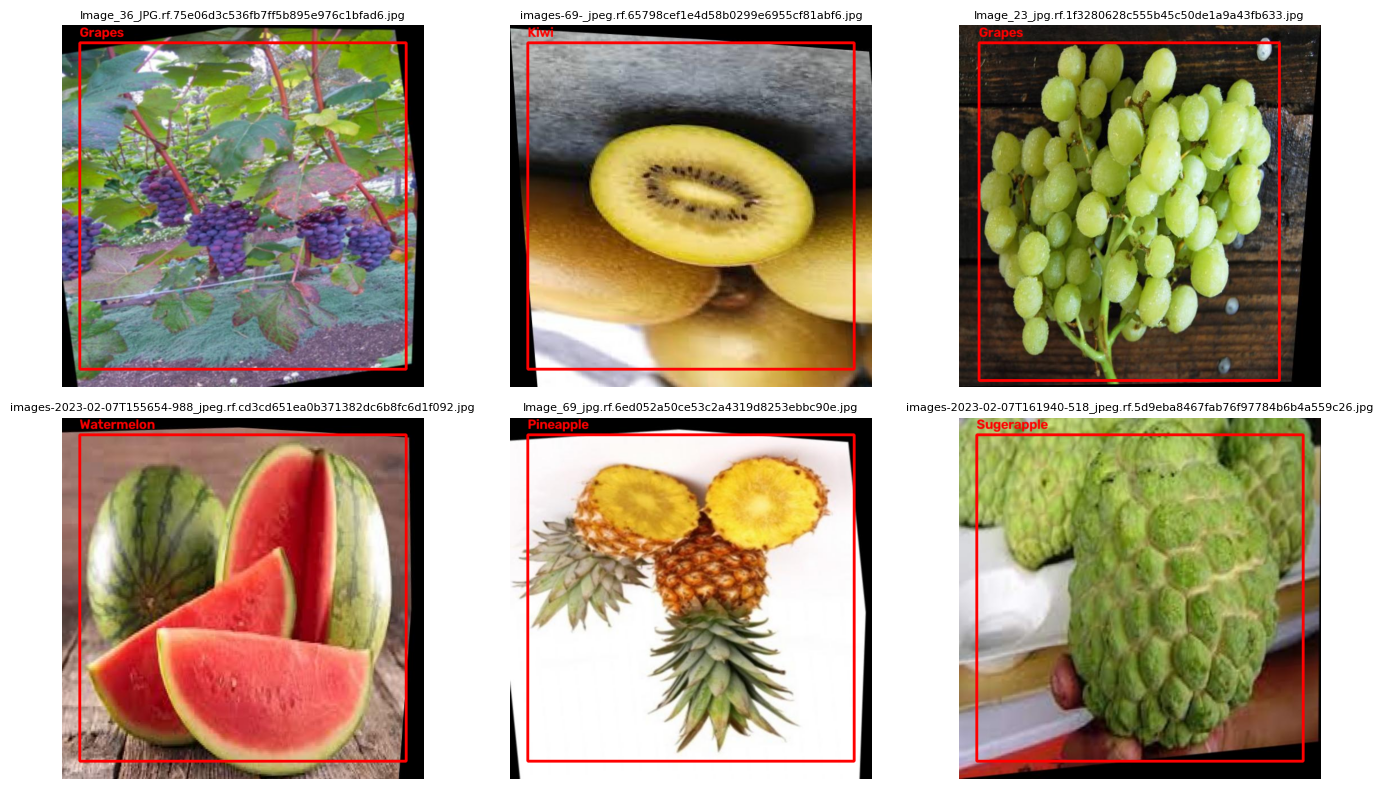

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

def quick_qc(split="train", n=6):
    img_dir = Path(OUTPUT_DIR) / split / "images"
    lbl_dir = Path(OUTPUT_DIR) / split / "labels"
    all_imgs = list(img_dir.iterdir())
    samples = random.sample(all_imgs, min(n, len(all_imgs)))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, img_path in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl_path = lbl_dir / (img_path.stem + ".txt")

        if lbl_path.exists() and lbl_path.read_text().strip():
            for line in lbl_path.read_text().strip().split("\n"):
                cls_id, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = int((xc - bw/2)*w), int((yc - bh/2)*h)
                x2, y2 = int((xc + bw/2)*w), int((yc + bh/2)*h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                cv2.putText(img, CLASS_NAMES[int(cls_id)], (x1, max(y1-10, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

quick_qc("train", n=6)

In [ ]:
model = YOLO(BASE_MODEL)

model.train(
    data=str(NEW_DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    patience=15,
    verbose=True,
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_prepared/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_detector, nbs=64, nms=None, opset=None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782cdadb7ee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
import shutil

metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

best_weights_path = f"{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
os.makedirs(MODEL_DIR, exist_ok=True)
shutil.copy(best_weights_path, f"{MODEL_DIR}/best.pt")

print("\n[SELESAI] Model terbaik ada di:", best_weights_path)
print(f"Download manual {MODEL_DIR}/best.pt ke folder /model lokal kamu.")


Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,591 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1117.1±500.9 MB/s, size: 38.5 KB)
val: Scanning /content/data_prepared/valid/labels.cache... 187 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 52.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.1it/s 3.8s
                   all        187        248      0.893      0.841      0.896      0.835
                 Apple         16         16      0.882      0.933      0.949      0.938
                Banana         27         36      0.965      0.774      0.883      0.758
                Grapes         25         33      0.924      0.758      0.875      0.731
                  Kiwi         21         21      0.943          1      0.956       0.94
                 Mango         15      

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
shutil.copy(f"{MODEL_DIR}/best.pt", "/content/drive/MyDrive/Projek/Fruits Detection (Object Detection)/models/yolo26n_models.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Projek/Fruits Detection (Object Detection)/models/yolo26n_models.pt'

# **Inference**

Inference di lokal juga bisa dilakukan dengan menjalankan file **inference.py** di komputer lokal

In [ ]:
MODEL_PATH = "models/yolo26n_models.pt"
IMAGE_PATH = "images/2.jpg"
CONF_THRESHOLD = 0.4

In [41]:
model = YOLO(MODEL_PATH)
result = model.predict(source=IMAGE_PATH, conf=CONF_THRESHOLD, verbose=False)[0]
annotated_frame = result.plot()
annotated_frame_rgb = cv2.cvtColor(annotated_frame,cv2.COLOR_BGR2RGB)

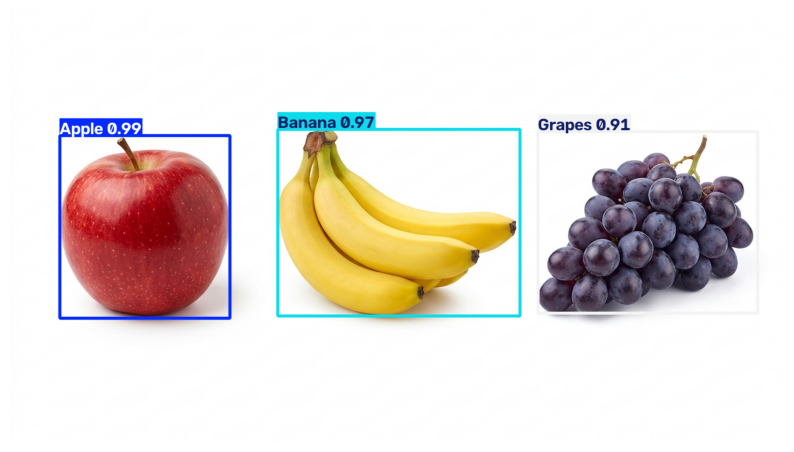

In [42]:
annotated_frame_rgb = cv2.cvtColor(annotated_frame,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(annotated_frame_rgb)
plt.axis("off")
plt.show()